In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

from hallucinations_kg.utils.logging import set_error_level

sys.path.append("..")

import itertools
import json
import warnings
from functools import partial
from statistics import mean
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import disable_caching, disable_progress_bar
from hydra import compose, initialize
from sklearn.metrics import precision_recall_curve

from hallucinations_kg.data.postprocessing import (
    add_allowed_nodes_and_relationships,
    parse_graph,
    postprocess_ents_rels,
)
from hallucinations_kg.data.utils import get_processed_dataset
from hallucinations_kg.defaults import PLOTS_PATH
from hallucinations_kg.metrics import auc_pr
from hallucinations_kg.models.baselines.selfcheckgpt import (
    SelfCheckGPTNLIPredictor,
    SelfCheckGPTPredictor,
)
from hallucinations_kg.models.predictor import (
    FactOccurrencePredictor,
    RandomFactPredictor,
)
from hallucinations_kg.models.prompt_predictor import FactPromptPredictor, FactTextPromptPredictor
from hallucinations_kg.models.sentence_predictor import (
    MostFrequentSentencePredictor,
    RandomSentencePredictor,
)
from hallucinations_kg.prediction.prediction import (
    add_sentence_predictor_results,
)

disable_caching()
disable_progress_bar()
set_error_level()
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
sns.set_palette("colorblind")

## Loading

In [3]:
with initialize(version_base="1.3", config_path=str("config")):
    cfg = compose(
        config_name="predict",
        overrides=[
            "processed_dataset=wiki_bio_sentence_with_prompt_answers",
            "llm=api/Llama-3.1-70B-Instruct",
        ],
    )

dataset = get_processed_dataset(cfg.processed_dataset)

In [4]:
response_column = cfg.processed_dataset.original_dataset.response_column
restrictions_column = cfg.processed_dataset.original_dataset.response_column
response_sentences_column = cfg.processed_dataset.original_dataset.response_sentences_column
samples_column = cfg.processed_dataset.original_dataset.samples_column

dataset = dataset.map(
    partial(
        add_allowed_nodes_and_relationships,
        restrictions_column=restrictions_column,
        response_sentences_column=response_sentences_column,
    )
)
dataset = dataset.map(
    partial(
        parse_graph,
        samples_column=samples_column,
        sentences_column=response_sentences_column,
        restrict=True,
    )
)
dataset = dataset.map(partial(postprocess_ents_rels, response_column=response_column))

In [5]:
SENTENCE_PREDICTOR_AGGREGATION_FUNCTIONS = [
    (FactOccurrencePredictor, mean),
    (FactOccurrencePredictor, max),
    (RandomFactPredictor, mean),
    (MostFrequentSentencePredictor, None),
    (RandomSentencePredictor, None),
    (FactPromptPredictor, mean),
    (FactPromptPredictor, max),
    (FactTextPromptPredictor, mean),
    (FactTextPromptPredictor, max),
    (SelfCheckGPTPredictor, None),
    (SelfCheckGPTNLIPredictor, None),
]

for name, ds in dataset.items():
    y_true = list(itertools.chain.from_iterable(ds["binary_annotation"]))
    ds = ds.map(
        partial(
            add_sentence_predictor_results,
            sentences_column=response_sentences_column,
            samples_column=samples_column,
            y_true=y_true,
            predictor_aggregation_functions=SENTENCE_PREDICTOR_AGGREGATION_FUNCTIONS,
        )
    )
    dataset[name] = ds

In [6]:
df = dataset["evaluation"].to_pandas()

In [7]:
SENTENCE_SCORE_COLUMNS = [col for col in df.columns if col.startswith("sent_score_")]
COLUMNS_TO_EXPLODE = [
    "gpt3_sentences",
    "gpt3_sentences_graph",
    "binary_annotation",
] + SENTENCE_SCORE_COLUMNS

sentence_df = df.explode(COLUMNS_TO_EXPLODE)

In [8]:
def parse_params(params: str) -> dict[str, Any]:
    return json.loads(params.replace("'", '"'))


results = []
for col in SENTENCE_SCORE_COLUMNS:
    y_pred = sentence_df[col]
    y_true = sentence_df.binary_annotation.to_numpy(dtype=int)
    y_pred = [x if pd.notna(x) else 0.5 for x in y_pred]

    auc_pr_hallucination = auc_pr(y_true, y_pred) * 100
    prec_hall, recall_hall, thresholds_hall = precision_recall_curve(y_true, y_pred)

    y_true_factual = 1 - y_true
    y_pred_factual = 1 - np.array(y_pred)

    auc_pr_factual = auc_pr(y_true_factual, y_pred_factual) * 100
    prec_fact, recall_fact, thresholds_fact = precision_recall_curve(y_true_factual, y_pred_factual)

    results.append(
        {
            "col": col,
            **parse_params(col.split("__")[-1]),
            "auc_hallucination": auc_pr_hallucination,
            "auc_factuality": auc_pr_factual,
            "auc_mean": mean([auc_pr_hallucination, auc_pr_factual]),
            "Precision_hall": prec_hall,
            "Recall_hall": recall_hall,
            "Thresholds_hall": thresholds_hall,
            "Precision_fact": prec_fact,
            "Recall_fact": recall_fact,
            "Thresholds_fact": thresholds_fact,
        }
    )

results = pd.DataFrame(results)

In [9]:
proba_results = pd.read_json("data/baselines/proba_metrics/wiki_bio/results.json")
proba_results["method_name"] = proba_results["col"].map(
    {
        "sent_score_mean_neg_log_probs": "Avg($-$log$p$)",
        "sent_score_max_neg_log_probs": "Max($-$log$p$)",
        "sent_score_mean_entropies": "Avg($\mathcal{H}$)",
        "sent_score_max_entropies": "Max($\mathcal{H}$)",
    }
)
proba_results = proba_results.rename(columns={"method_name": "Method"})
random_auc_hall = (sentence_df.binary_annotation == 1).mean() * 100
random_auc_fact = (sentence_df.binary_annotation == 0).mean() * 100


random_result = pd.DataFrame(
    [
        {
            "Method": "RandomSentence",
            "auc_hallucination": random_auc_hall,
            "auc_factuality": random_auc_fact,
            "auc_mean": mean([random_auc_hall, random_auc_fact]),
        }
    ]
)

In [10]:
with open("data/baselines/attention_score/wiki_bio/results.json", "r") as f:
    attn_score = json.load(f)


def get_method_name(row: pd.Series) -> str:
    if "attn_score_relative" in row["col"]:
        return "AttentionScore (Relative)"
    elif "attn_score_absolute" in row["col"]:
        return "AttentionScore (Absolute)"
    else:
        raise ValueError(f"Unknown column: {row['col']}")


attn_score_df = pd.DataFrame(
    [attn_score["sentence_best_relative_results"], attn_score["sentence_best_absolute_results"]]
)
attn_score_df["method_name"] = attn_score_df.apply(get_method_name, axis=1)

attn_score_df = attn_score_df.rename(columns={"method_name": "Method"})

In [11]:
mask = (
    results.fact_predictor.str.contains("RandomFact")
    | results.fact_predictor.str.contains("FactSelfCheck-KG")
    | results.fact_predictor.str.contains("FactSelfCheck-Text")
    | results.sentence_predictor.str.contains("SelfCheckGPT")
)


def get_method_name(row: pd.Series) -> str:
    if row["sentence_predictor"] == "SelfCheckGPT-reproduced":
        return "SelfCheckGPT (Prompt)"
    elif row["sentence_predictor"] == "SelfCheckGPT-NLI-reproduced":
        return "SelfCheckGPT (NLI)"
    else:
        if row["fact_predictor"] == "FactOccurrence":
            fact_predictor = "FactKGOccurrence"
        elif row["fact_predictor"] == "FactPrompt":
            fact_predictor = "FactKGPrompt"
        elif row["fact_predictor"] == "FactTextPrompt":
            fact_predictor = "FactTextPrompt"
        else:
            fact_predictor = row["fact_predictor"]
        return fact_predictor


results["Method"] = results.apply(get_method_name, axis=1)
to_report = results[mask]
to_report = pd.concat([to_report, proba_results, attn_score_df, random_result])
to_report = to_report.rename(
    columns={
        "auc_hallucination": "AUC-PR Hallucination",
        "auc_factuality": "AUC-PR Factuality",
        "auc_mean": "Avg. AUC-PR",
        "agg_func": "Agg",
    }
)

to_report["Agg"] = to_report["Agg"].fillna("-")
to_report["Method"] = to_report["Method"].str.replace("SelfCheckGPT", "SCGPT")
to_report["Method"] = to_report["Method"].str.replace("FactSelfCheck", "FSC")
to_report = to_report[["Method", "Agg", "AUC-PR Hallucination", "AUC-PR Factuality", "Avg. AUC-PR"]]
to_report = to_report.sort_values(by="AUC-PR Hallucination", ascending=False)
# to_report = to_report.rename(columns={"AUC-PR Hallucination": "AUC-PR"})
display(to_report)

print(to_report[to_report.Agg.str.contains("-")].to_latex(index=False, float_format="%.2f"))
print(to_report[~to_report.Agg.str.contains("-")].to_latex(index=False, float_format="%.2f"))

to_report = to_report[["Method", "Agg", "AUC-PR Hallucination"]]
print(to_report[to_report.Agg.str.contains("-")].to_latex(index=False, float_format="%.2f"))
print(to_report[~to_report.Agg.str.contains("-")])

,Method,Agg,AUC-PR Hallucination,AUC-PR Factuality,Avg. AUC-PR
9,SCGPT (Prompt),-,93.603953,74.301199,83.952576
10,SCGPT (NLI),-,92.496692,66.078161,79.287426
8,FSC-Text,max,92.451516,65.550777,79.001146
6,FSC-KG (LLM-based),max,91.821016,64.644055,78.232535
7,FSC-Text,mean,91.012965,63.773989,77.393477
5,FSC-KG (LLM-based),mean,90.242020,62.954454,76.598237
1,FSC-KG (Frequency-based),max,88.476019,53.857313,71.166666
0,FSC-KG (Frequency-based),mean,88.246039,55.274397,71.760218
0,AttentionScore (Relative),-,83.847219,51.623702,67.735461
3,Max($\mathcal{H}$),-,82.557129,41.802852,62.179991


\begin{tabular}{llrrr}
\toprule
Method & Agg & AUC-PR Hallucination & AUC-PR Factuality & Avg. AUC-PR \\
\midrule
SCGPT (Prompt) & - & 93.60 & 74.30 & 83.95 \\
SCGPT (NLI) & - & 92.50 & 66.08 & 79.29 \\
AttentionScore (Relative) & - & 83.85 & 51.62 & 67.74 \\
Max($\mathcal{H}$) & - & 82.56 & 41.80 & 62.18 \\
Avg($-$log$p$) & - & 79.20 & 44.11 & 61.65 \\
Avg($\mathcal{H}$) & - & 79.02 & 49.18 & 64.10 \\
Max($-$log$p$) & - & 78.41 & 33.59 & 56.00 \\
AttentionScore (Absolute) & - & 77.95 & 42.23 & 60.09 \\
RandomSentence & - & 72.96 & 27.04 & 50.00 \\
\bottomrule
\end{tabular}

\begin{tabular}{llrrr}
\toprule
Method & Agg & AUC-PR Hallucination & AUC-PR Factuality & Avg. AUC-PR \\
\midrule
FSC-Text & max & 92.45 & 65.55 & 79.00 \\
FSC-KG (LLM-based) & max & 91.82 & 64.64 & 78.23 \\
FSC-Text & mean & 91.01 & 63.77 & 77.39 \\
FSC-KG (LLM-based) & mean & 90.24 & 62.95 & 76.60 \\
FSC-KG (Frequency-based) & max & 88.48 & 53.86 & 71.17 \\
FSC-KG (Frequency-based) & mean & 88.25 & 55.27 & 71.76 

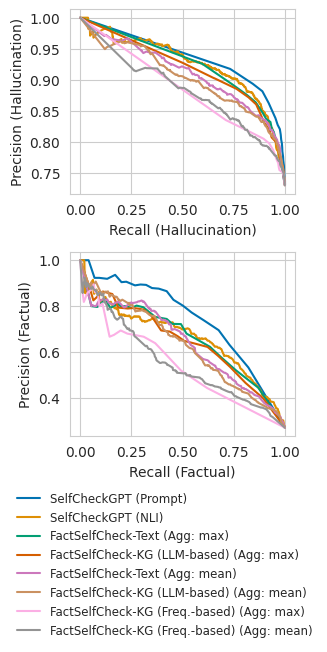

In [12]:
to_plot = results.copy()
to_plot["Method"] = to_plot.apply(
    lambda row: row["Method"] + f" (Agg: {row['agg_func']})"
    if pd.notna(row["agg_func"])
    else row["Method"],
    axis=1,
)
to_plot = to_plot.dropna(subset=["Method"])
to_plot = to_plot[to_plot["Method"].str.contains("Check")]
to_plot["Method"] = to_plot["Method"].str.replace("Frequency", "Freq.")
to_plot["Method"] = to_plot["Method"].str.replace(
    "SelfCheckGPT-reproduced", "SelfCheckGPT (Prompt)"
)
hue_order = to_plot.sort_values(by="auc_hallucination", ascending=False).Method.tolist()
fig, axes = plt.subplots(2, 1, figsize=(3.5, 5))
sns.lineplot(
    data=to_plot.explode(["Precision_hall", "Recall_hall"]),
    x="Recall_hall",
    y="Precision_hall",
    hue="Method",
    ax=axes[0],
    hue_order=hue_order,
)
sns.lineplot(
    data=to_plot.explode(["Recall_fact", "Precision_fact"]),
    x="Recall_fact",
    y="Precision_fact",
    hue="Method",
    ax=axes[1],
    hue_order=hue_order,
)
axes[0].set_ylabel("Precision (Hallucination)")
axes[1].set_ylabel("Precision (Factual)")
axes[0].set_xlabel("Recall (Hallucination)")
axes[1].set_xlabel("Recall (Factual)")
axes[0].get_legend().remove()
fig.tight_layout()
sns.move_legend(
    axes[1],
    "lower center",
    bbox_to_anchor=(0.42, -1.15),
    ncol=1,
    title=None,
    frameon=False,
    fontsize=8.5,
)
plt.savefig(PLOTS_PATH / "pr_curve_extended.pdf", dpi=600, bbox_inches="tight")

In [13]:
[selfcheckgpt_col] = [col for col in results.col if "SelfCheckGPT-reproduced" in col]
p, r, t = results[results.col == selfcheckgpt_col][
    ["Precision_hall", "Recall_hall", "Thresholds_hall"]
].iloc[0]
f1 = 2 * p * r / (p + r)
best_t = t[f1.argmax()]
print(f"Best threshold selfcheckgpt: {best_t}")

Best threshold selfcheckgpt: 0.75


In [14]:
cols = ["gpt3_text_entities", "gpt3_text_relations"]
stats = []

for col in cols:
    print(col)
    stats.append(
        {
            "col": col,
            "mean": df[col].apply(len).mean(),
            "min": df[col].apply(len).min(),
            "max": df[col].apply(len).max(),
            "# entries with 0 elements": (df[col].apply(len) == 0).sum(),
            "% entries with 0 elements": (df[col].apply(len) == 0).sum() / len(df) * 100,
        }
    )

for col in ["gpt3_sentences_graph"]:
    stats.append(
        {
            "col": col,
            "mean": sentence_df[col].apply(len).mean(),
            "min": sentence_df[col].apply(len).min(),
            "max": sentence_df[col].apply(len).max(),
            "# entries with 0 elements": (sentence_df[col].apply(len) == 0).sum(),
            "% entries with 0 elements": (sentence_df[col].apply(len) == 0).sum()
            / len(sentence_df)
            * 100,
        }
    )

print(pd.DataFrame(stats).set_index("col").T.to_latex(float_format="%.2f"))

gpt3_text_entities
gpt3_text_relations
\begin{tabular}{lrrr}
\toprule
col & gpt3_text_entities & gpt3_text_relations & gpt3_sentences_graph \\
\midrule
mean & 24.85 & 21.18 & 3.24 \\
min & 11.00 & 5.00 & 0.00 \\
max & 282.00 & 163.00 & 85.00 \\
# entries with 0 elements & 0.00 & 0.00 & 22.00 \\
% entries with 0 elements & 0.00 & 0.00 & 1.15 \\
\bottomrule
\end{tabular}

